Loaded: (2268, 13)
consensus_label
active_single      1502
inactive_single     463
active              286
inactive             17
Name: count, dtype: int64
FIGDIR exists: True C:\Users\Besitzer\Desktop\M3_Project\Figures


[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerator
[20:41:49] DEPRECATION WARNING: please use MorganGenerat

X shape: (2268, 2048)
y length: 2268
scaffolds length: 2268
(2268, 2048)
2268
2268
[ROC-CV] Fold 01 ROC-AUC = 0.9663 | n_test=454
[ROC-CV] Fold 02 ROC-AUC = 0.9404 | n_test=454
[ROC-CV] Fold 03 ROC-AUC = 0.9856 | n_test=454
[ROC-CV] Fold 04 ROC-AUC = 0.9471 | n_test=453
[ROC-CV] Fold 05 ROC-AUC = 0.9616 | n_test=453

[ROC-CV] mean ROC-AUC = 0.9602 ± 0.0177 (n_folds=5)
[SAVED] C:\Users\Besitzer\Desktop\M3_Project\Figures\CV5_scaffold_ROC.png
[SAVED] C:\Users\Besitzer\Desktop\M3_Project\Figures\CV5_scaffold_ROC.pdf


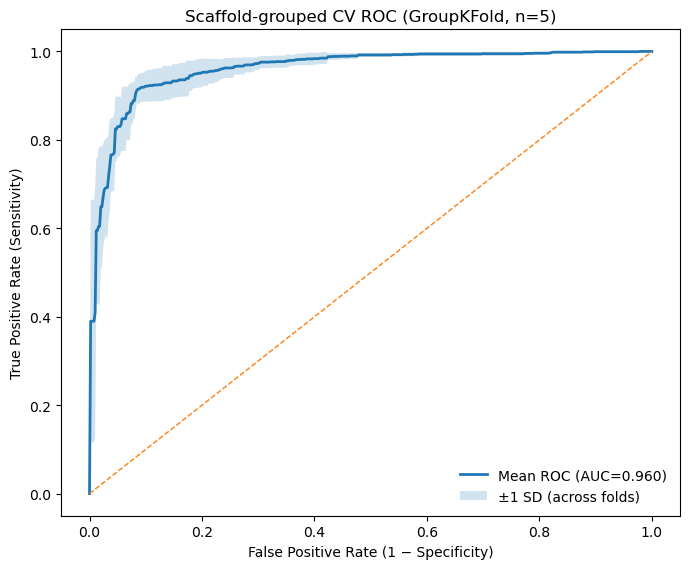

[ROC-CV] Fold 01 ROC-AUC = 0.9663 | n_test=454
[ROC-CV] Fold 02 ROC-AUC = 0.9404 | n_test=454
[ROC-CV] Fold 03 ROC-AUC = 0.9856 | n_test=454
[ROC-CV] Fold 04 ROC-AUC = 0.9471 | n_test=453
[ROC-CV] Fold 05 ROC-AUC = 0.9616 | n_test=453

[ROC-CV] mean ROC-AUC = 0.9602 ± 0.0177 (n_folds=5)
[Y-RAND] 10/100
[Y-RAND] 20/100
[Y-RAND] 30/100
[Y-RAND] 40/100
[Y-RAND] 50/100
[Y-RAND] 60/100
[Y-RAND] 70/100
[Y-RAND] 80/100
[Y-RAND] 90/100
[Y-RAND] 100/100

[Y-RAND] Real mean ROC-AUC: 0.9602
[Y-RAND] Perm mean ROC-AUC: 0.4972 ± 0.019
[Y-RAND] Empirical p-value (perm >= real): 0.009900990099009901
[SAVED] C:\Users\Besitzer\Desktop\M3_Project\Figures\Yrand_scaffold_ROC.png
[SAVED] C:\Users\Besitzer\Desktop\M3_Project\Figures\Yrand_scaffold_ROC.pdf


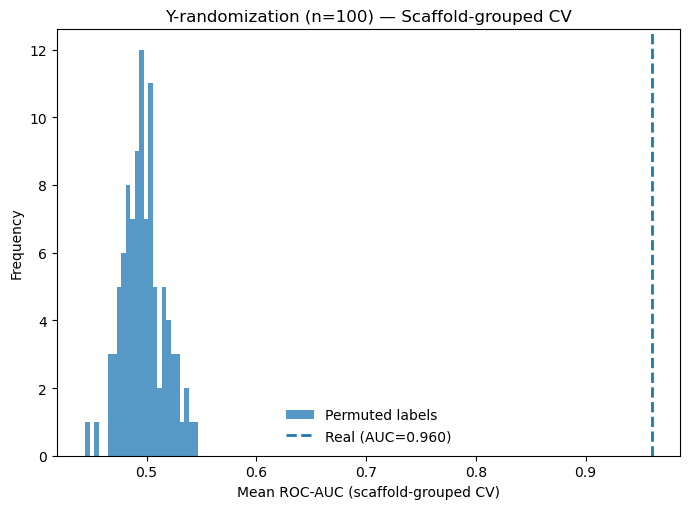

In [9]:
# =============================================================================
# Scaffold-grouped ROC-CV + Y-randomization (response permutation) — ROC-AUC
# Works with your existing pipeline, X (numpy array), y (0/1), scaffolds (array-like)
#
# Requirements: numpy, matplotlib, scikit-learn
# =============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.base import clone
from rdkit.Chem import AllChem
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.ML.Cluster import Butina
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Geometry import rdGeometry

DATA_PATH = r"C:\Users\Besitzer\Desktop\M3_databases\ChEMBL_M3_consensus_labels_more_negatives_with_meta.csv"
df = pd.read_csv(DATA_PATH)

print("Loaded:", df.shape)
print(df["consensus_label"].value_counts())

# ================================
# 1. Compute Morgan fingerprints
# ================================

FIGDIR = r"C:\Users\Besitzer\Desktop\M3_Project\Figures"
os.makedirs(FIGDIR, exist_ok=True)
print("FIGDIR exists:", os.path.exists(FIGDIR), FIGDIR)

def smiles_to_fp(smiles, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)

df["fp"] = df["smiles"].apply(smiles_to_fp)

# Remove failed structures
df = df[df["fp"].notna()].copy()

# ================================
# 2. Convert fingerprints to numpy
# ================================

def fps_to_numpy(fps, n_bits=2048):
    arr = np.zeros((len(fps), n_bits), dtype=int)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, arr[i])
    return arr

X = fps_to_numpy(df["fp"].tolist(), n_bits=2048)

# ================================
# 3. Labels
# ================================

y = df["consensus_label"].isin(["active", "active_single"]).astype(int).values

# ================================
# 4. Scaffolds
# ================================

def smiles_to_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

df["scaffold"] = df["smiles"].apply(smiles_to_scaffold)
scaffolds = df["scaffold"].values

# ================================
# 5. Sanity check
# ================================

print("X shape:", X.shape)
print("y length:", len(y))
print("scaffolds length:", len(scaffolds))
def scaffold_cv_roc(
    pipeline,
    X,
    y,
    scaffolds,
    n_splits=5,
    random_state=0,
    plot=True,
    out_prefix=None,   # e.g. r"C:\Users\...\figures\CV5_scaffold_ROC"
):
    """
    Scaffold-grouped CV ROC curves + ROC-AUC summary.

    Returns dict:
      - mean_auc, std_auc
      - fold_aucs (list)
      - fpr_grid, mean_tpr, std_tpr (for plotting)
    """
    gkf = GroupKFold(n_splits=int(n_splits))

    # Common FPR grid for mean ROC curve
    fpr_grid = np.linspace(0.0, 1.0, 501)

    fold_aucs = []
    tprs = []

    for fold_i, (tr, te) in enumerate(gkf.split(X, y, groups=scaffolds), start=1):
        model = clone(pipeline)
        model.fit(X[tr], y[tr])

        y_prob = model.predict_proba(X[te])[:, 1]

        auc = roc_auc_score(y[te], y_prob)
        fold_aucs.append(float(auc))

        fpr, tpr, _ = roc_curve(y[te], y_prob)
        # Interpolate TPR to common grid for averaging
        tpr_i = np.interp(fpr_grid, fpr, tpr)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)

        print(f"[ROC-CV] Fold {fold_i:02d} ROC-AUC = {auc:.4f} | n_test={len(te)}")

    tprs = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = float(np.mean(fold_aucs))
    std_auc  = float(np.std(fold_aucs, ddof=1)) if len(fold_aucs) > 1 else 0.0

    print(f"\n[ROC-CV] mean ROC-AUC = {mean_auc:.4f} ± {std_auc:.4f} (n_folds={n_splits})")

    if plot:
        fig, ax = plt.subplots(figsize=(7.0, 5.8))
        # Plot mean ROC
        ax.plot(fpr_grid, mean_tpr, lw=2, label=f"Mean ROC (AUC={mean_auc:.3f})")
        # Shade ±1 SD
        ax.fill_between(
            fpr_grid,
            np.clip(mean_tpr - std_tpr, 0, 1),
            np.clip(mean_tpr + std_tpr, 0, 1),
            alpha=0.20,
            label="±1 SD (across folds)"
        )
        # Diagonal
        ax.plot([0, 1], [0, 1], ls="--", lw=1)

        ax.set_xlabel("False Positive Rate (1 − Specificity)")
        ax.set_ylabel("True Positive Rate (Sensitivity)")
        ax.set_title(f"Scaffold-grouped CV ROC (GroupKFold, n={n_splits})")
        ax.legend(frameon=False, loc="lower right")
        fig.tight_layout()

        if out_prefix:
            fig.savefig(out_prefix + ".png", dpi=300, bbox_inches="tight")
            fig.savefig(out_prefix + ".pdf", bbox_inches="tight")
            print("[SAVED]", out_prefix + ".png")
            print("[SAVED]", out_prefix + ".pdf")

        plt.show()
        plt.close(fig)

    return {
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "fold_aucs": fold_aucs,
        "fpr_grid": fpr_grid,
        "mean_tpr": mean_tpr,
        "std_tpr": std_tpr,
    }


def y_randomization_roc_auc(
    pipeline,
    X,
    y,
    scaffolds,
    n_splits=5,
    n_permutations=100,
    random_state=42,
    plot=True,
    out_prefix=None,  # e.g. r"C:\Users\...\figures\Yrand_ROC"
):
    """
    Y-randomization under scaffold-grouped CV.
    Returns:
      - real_mean_auc
      - perm_mean_aucs (np.array)
      - empirical_p (one-sided: perm >= real)
    """
    rng = np.random.RandomState(int(random_state))

    # Real AUC from scaffold-CV (no plotting here)
    real = scaffold_cv_roc(
        pipeline, X, y, scaffolds,
        n_splits=n_splits,
        plot=False
    )
    real_mean_auc = real["mean_auc"]

    # Permutations
    perm_mean_aucs = np.zeros(int(n_permutations), dtype=float)

    gkf = GroupKFold(n_splits=int(n_splits))

    for i in range(int(n_permutations)):
        y_perm = rng.permutation(y)

        fold_aucs = []
        for tr, te in gkf.split(X, y_perm, groups=scaffolds):
            model = clone(pipeline)
            model.fit(X[tr], y_perm[tr])

            y_prob = model.predict_proba(X[te])[:, 1]
            fold_aucs.append(roc_auc_score(y_perm[te], y_prob))

        perm_mean_aucs[i] = float(np.mean(fold_aucs))

        if (i + 1) % 10 == 0 or (i + 1) == n_permutations:
            print(f"[Y-RAND] {i+1}/{n_permutations}")

    # Empirical p-value (one-sided)
    empirical_p = (np.sum(perm_mean_aucs >= real_mean_auc) + 1) / (len(perm_mean_aucs) + 1)

    print("\n[Y-RAND] Real mean ROC-AUC:", round(real_mean_auc, 4))
    print("[Y-RAND] Perm mean ROC-AUC:", round(float(np.mean(perm_mean_aucs)), 4),
          "±", round(float(np.std(perm_mean_aucs, ddof=1)), 4))
    print("[Y-RAND] Empirical p-value (perm >= real):", empirical_p)

    if plot:
        fig, ax = plt.subplots(figsize=(7.0, 5.2))
        ax.hist(perm_mean_aucs, bins=25, alpha=0.75, label="Permuted labels")
        ax.axvline(real_mean_auc, ls="--", lw=2, label=f"Real (AUC={real_mean_auc:.3f})")

        ax.set_xlabel("Mean ROC-AUC (scaffold-grouped CV)")
        ax.set_ylabel("Frequency")
        ax.set_title(f"Y-randomization (n={n_permutations}) — Scaffold-grouped CV")
        ax.legend(frameon=False, loc="best")
        fig.tight_layout()

        if out_prefix:
            fig.savefig(out_prefix + ".png", dpi=300, bbox_inches="tight")
            fig.savefig(out_prefix + ".pdf", bbox_inches="tight")
            print("[SAVED]", out_prefix + ".png")
            print("[SAVED]", out_prefix + ".pdf")

        plt.show()
        plt.close(fig)

    return real_mean_auc, perm_mean_aucs, empirical_p


# =============================================================================
# EXAMPLE USAGE
# =============================================================================
# You must already have:
#   - X: numpy array shape (n_samples, n_features)
#   - y: numpy array shape (n_samples,) with 0/1 labels
#   - scaffolds: array-like shape (n_samples,) scaffold strings
#   - pipeline: sklearn Pipeline (e.g., scaler + LogisticRegression)
#
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        solver="liblinear",
        penalty="l2",
        class_weight="balanced",
        max_iter=5000
    ))
])
y = df["consensus_label"].isin(["active", "active_single"]).astype(int).values

print(X.shape)
print(len(y))
print(len(scaffolds))


cv_res = scaffold_cv_roc(
    pipeline, X, y, scaffolds, 
    n_splits=5, 
    out_prefix=r"C:\Users\Besitzer\Desktop\M3_Project\Figures\CV5_scaffold_ROC")
real_auc, perm_aucs, pval = y_randomization_roc_auc(
    pipeline, X, y, scaffolds, 
    n_splits=5, 
    n_permutations=100,
    out_prefix=r"C:\Users\Besitzer\Desktop\M3_Project\Figures\Yrand_scaffold_ROC")
# =============================================================================
